In [1]:
# 1. Setup + fetch data
import sys, warnings
from pathlib import Path

_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb": p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate; break
    if ROOT: break
if not ROOT: raise FileNotFoundError("Open Signal_Monitor in Cursor.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import plotly.graph_objects as go
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(mpl.rcParamsDefault)

from vol_surface import VolSurfaceConfig, VolSurfaceStudy, latest_business_session
from surface_sentiment import SurfaceDeltaPCA, SurfacePCAConfig
from data_fetcher import RateLimiter, SafeFetchSession

# Define the target underlying index ticker: "US..SPX", "US..IXIC" (Nasdaq), or "US..DJI" (Dow Jones)
UNDERLYING_TICKER = "US..SPX"

cfg = VolSurfaceConfig(underlying=UNDERLYING_TICKER, max_dte=60, lookback_days=15)

# If other index tickers are targeted and local cache folder doesn't exist yet, 
# load_history using use_demo_if_empty=True will automatically load full simulation option matrices on the fly
try:
    import futu as ft
    limiter = RateLimiter(600)
    session = SafeFetchSession(limiter, cfg)
    ctx = ft.OpenQuoteContext(host=cfg.host, port=cfg.port)
    df = session.fetch_and_cache(ctx, max_retries=3)
    ctx.close()
    print(f"Live: {len(df)} contracts")
except Exception as e:
    print(f"Live failed: {e}, using demo/synthetic curves for {UNDERLYING_TICKER}")
    df = None

study = VolSurfaceStudy(cfg)
study.load_history(use_demo_if_empty=True) # Enabled demo simulation fallback for NDX/DJI
dates = sorted(study.surfaces.keys())
print(f"Loaded {len(dates)} sessions for {UNDERLYING_TICKER}")
print(dates[0].strftime("%Y-%m-%d"), "->", dates[-1].strftime("%Y-%m-%d"))

2026-07-04 23:18:11,202 | 17472 | 9300 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479191839499631275(1) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x000001E959A46EA0>
Live: 7437 contracts
2026-07-04 23:18:50,462 | 17472 | 17476 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(1) reason=CallClose
Loaded 11 sessions for US..SPX
2026-06-19 -> 2026-07-03


2026-07-04 23:19:50,126 | 17472 | 17476 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(2) reason=CallClose


In [2]:
# 2. Run analysis + PCA

result = study.analyze()
today_f = result["today"]

pca = SurfaceDeltaPCA(SurfacePCAConfig(n_components=4, baseline_window=21))
pca_result = pca.fit(surfaces=study.surfaces)
evr = pca_result["explained_variance_ratio"]

hist_scores = pca_result["score_history"]
score_dates = pca_result["score_dates"]
composite = -(hist_scores[:, 0] / np.nanstd(hist_scores[:, 0])
              + hist_scores[:, 1] / np.nanstd(hist_scores[:, 1]))

print(f"PCA: PC1={evr[0]:.1%} PC2={evr[1]:.1%} PC3={evr[2]:.1%}")
today_scores = hist_scores[-1]
sentiment = pca.sentiment_from_scores(today_scores, hist_scores)
print(f"Today: z_PC1={today_scores[0]:+.2f} z_PC2={today_scores[1]:+.2f}")

2026-07-04 23:19:46,298 | 17472 | 9300 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479192238355076304(2) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x000001E95B7F6810>
PCA: PC1=100.0% PC2=0.0% PC3=0.0%
Today: z_PC1=+15.04 z_PC2=-0.02


In [3]:
# 3. Bloomberg-style 3D vol surface with IV/local vol toggle (using Moneyness K/S)

# Call the encapsulated 3D Moneyness graph visualization method
fig = study.plot_bloomberg_3d_surface()
fig.show()

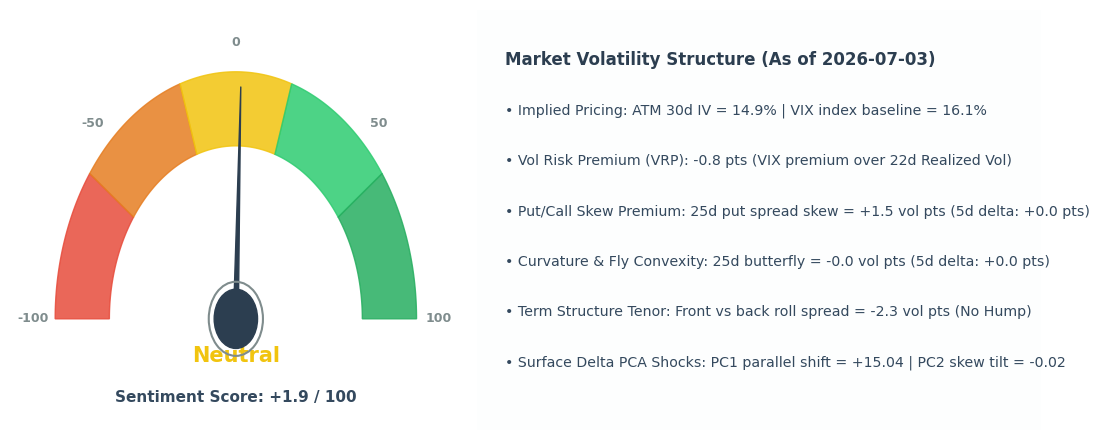

In [4]:
# 4. Compass Gauge Speedometer (Bull / Bear) & Sentiment Summary Bulletpoints

# Call the encapsulated speedometer dual-panel plotting engine
study.plot_sentiment_gauge(result=result, today_scores=today_scores, sentiment=sentiment)